### Package Installation

In [18]:
! pip install seaborn


[notice] A new release of pip is available: 20.0.2 -> 26.0
[notice] To update, run: pip install --upgrade pip


### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

### Election Data

Election Years:  
* 2005, 2010, 2015, 2017, 2019, 2024 

Parties:  
* 2005
    * Conservatives, Labour, Lib Dem
* 2010
    * Cons, Lab, LibD
* 2015 
    * Cons, Lab, LibD, Green,  UKIP, Plaid, SNP
* 2017
    * Cons, Lab, Libd, Green, Plaid, SNP, UKIP
* 2019
    * Cons, Lab, SNP, Libd, Green, Plaid, Brexit
* 2024
    * Cons, Lab, Libd, SNP, Reform, Green, Plaid


In [7]:
# working class election results
election_results = {
    'election':   [2024, 2019, 2017, 2015, 2010, 2005, 
                   2024, 2019, 2017, 2015, 2010, 2005, 
                   2024, 2019, 2017, 2015, 2010, 2005, 
                   2024, 2019, 2017, 2015,
                   2024,
                   2024, 2019, 2017, 2015,
                   2024, 2019, 2017, 2015,
                   2019,
                   2017, 2015],
    
    'party': ['Conservatives', 'Conservatives', 'Conservatives', 'Conservatives', 'Conservatives', 'Conservatives',
              'Labour', 'Labour', 'Labour', 'Labour', 'Labour', 'Labour', 
              'Liberal Democrats', 'Liberal Democrats', 'Liberal Democrats', 'Liberal Democrats', 'Liberal Democrats', 'Liberal Democrats', 
              'SNP', 'SNP', 'SNP', 'SNP', 
              'Reform UK',
              'Green', 'Green', 'Green', 'Green', 
              'Plaid Cymru', 'Plaid Cymru', 'Plaid Cymru', 'Plaid Cymru', 
              'Brexit',
              'UKIP', 'UKIP'
              ],

    'c2_vote': [0.24,0.49,0.47,0.36,0.37,0.33, #Cons
                0.32,0.31,0.40,0.31,0.29,0.40, #Lab
                0.11,0.09,0.06,0.06,0.22,0.19, #Lib
                0.03,0.04,0.03,0.05,     #SNP
                0.20,                 #Reform
                0.06,0.03,0.01,0.03,     #Green
                0.01,0.00,0.00,0.01,      #Plaid
                0.03,                 #Brexit
                0.02,0.17                   #UKIP
               ],
    
    'de_vote': [0.23,0.47,0.41,0.29,0.31,0.25,    #Cons
                0.34,0.34,0.44,0.37,0.40,0.48,    #Lab
                0.10,0.08,0.05,0.06,0.17,0.18,    #Lib
                0.03,0.04,0.04,0.05,        #SNP
                0.19,                 #Reform 
                0.06,0.02,0.02,0.03,        #Green
                0.01,0.00,0.00,0.00,        #Plaid
                0.03,                 #Brexit
                0.04,0.18                   #UKIP
               ],
    
    'c2de_vote': [0.23,0.48,0.44,0.33,0.34,0.29,  #Cons
                  0.33,0.33,0.42,0.34,0.35,0.44,  #Lab
                  0.11,0.08,0.06,0.06,0.20,0.19,  #Lib
                  0.03,0.04,0.04,0.05,      #SNP
                  0.20,               #Reform 
                  0.06,0.02,0.01,0.03,      #Green
                  0.01,0.00,0.00,0.01,      #Plaid
                  0.03,               #Brexit
                  0.03,0.18                 #UKIP
                 ]

}



In [4]:
len(election_results['c2de_vote'])

34

Sources:
* 2024: https://www.ipsos.com/en-uk/uk-opinion-polls/how-britain-voted-in-the-2024-election
* 2024: https://yougov.co.uk/politics/articles/49978-how-britain-voted-in-the-2024-general-election
* 2019, 2017, 2015 are from YouGov
* 2010 and 2005 are from IPSOS

The IPSOS data groups SNP and Plaid together on 4% in 2024. For the purpose of analysis this is split equally: 2% each

In [8]:
final_election_df = pd.DataFrame(election_results)
final_election_df

,election,party,c2_vote,de_vote,c2de_vote
0,2024,Conservatives,0.24,0.23,0.23
1,2019,Conservatives,0.49,0.47,0.48
2,2017,Conservatives,0.47,0.41,0.44
3,2015,Conservatives,0.36,0.29,0.33
4,2010,Conservatives,0.37,0.31,0.34
5,2005,Conservatives,0.33,0.25,0.29
6,2024,Labour,0.32,0.34,0.33
7,2019,Labour,0.31,0.34,0.33
8,2017,Labour,0.40,0.44,0.42
9,2015,Labour,0.31,0.37,0.34


In [9]:
final_election_df.to_csv('final_vote.csv')

In [5]:
len(final_election_df)

34

In [8]:
def plot_over_time(demo):
    sns.lineplot(data=df, x='election', y=demo, hue='party', marker='o')
    years = sorted(df['election'].unique())
    plt.xticks(years)
    plt.legend(
        title='Political Parties',   
        bbox_to_anchor=(1.05, 1),    
        loc='upper left',            
        borderaxespad=0.             
    )
    plt.title(f'Working Class Vote Share Over Time ({demo[:-5]})')
    plt.ylabel('Vote Share (%)')
    plt.xlabel('Election Year')
    plt.show()

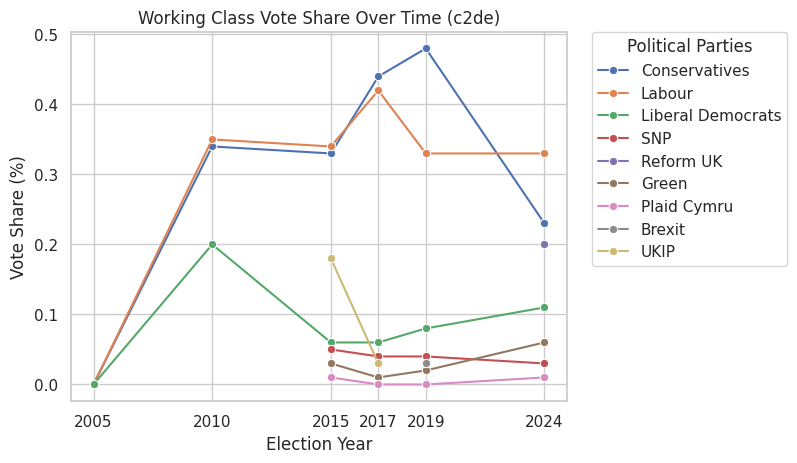

In [9]:
plot_over_time('c2de_vote')

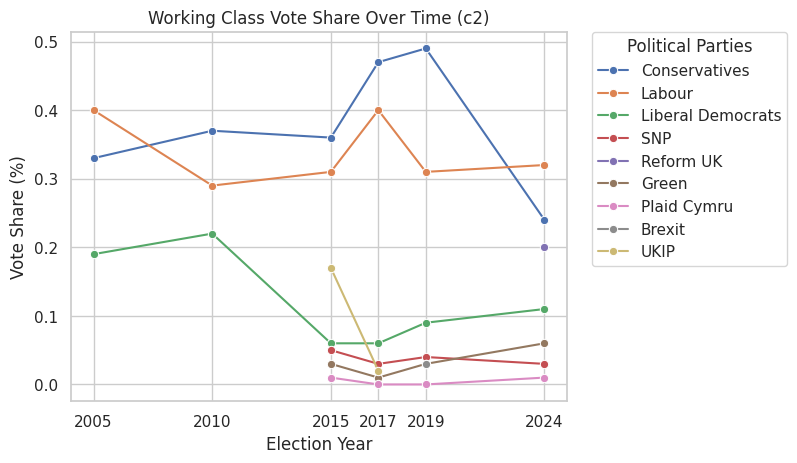

In [10]:
plot_over_time('c2_vote')

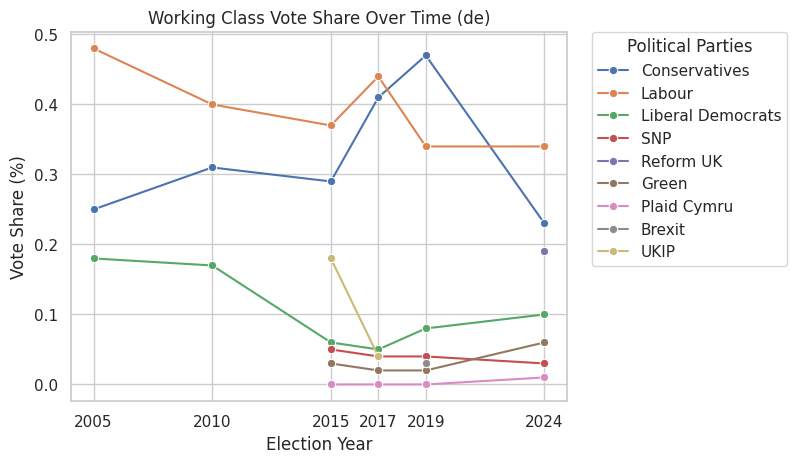

In [11]:
plot_over_time('de_vote')

In [12]:
def plot_per_party(year):
    df_year = df[df['election'] == year]
    df_melted = df_year.melt(id_vars='party', value_vars=['c2_vote', 'de_vote'], 
                             var_name='Demographic', value_name='Vote Share (%)')
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_melted, x='party', y='Vote Share (%)', hue='Demographic')
    plt.title(f'Party Comparison: C2 vs DE Vote Share ({year})')
    plt.xlabel("Party")
    plt.xticks(rotation=90)
    plt.show()

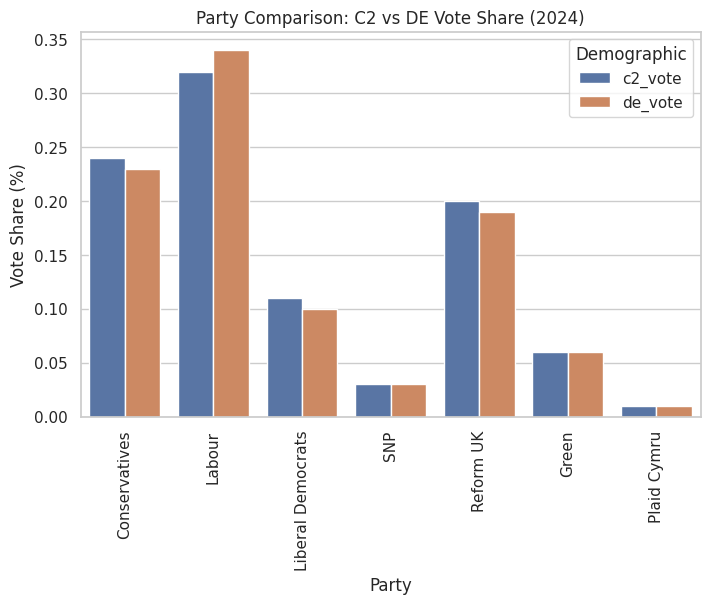

In [13]:
plot_per_party(2024)

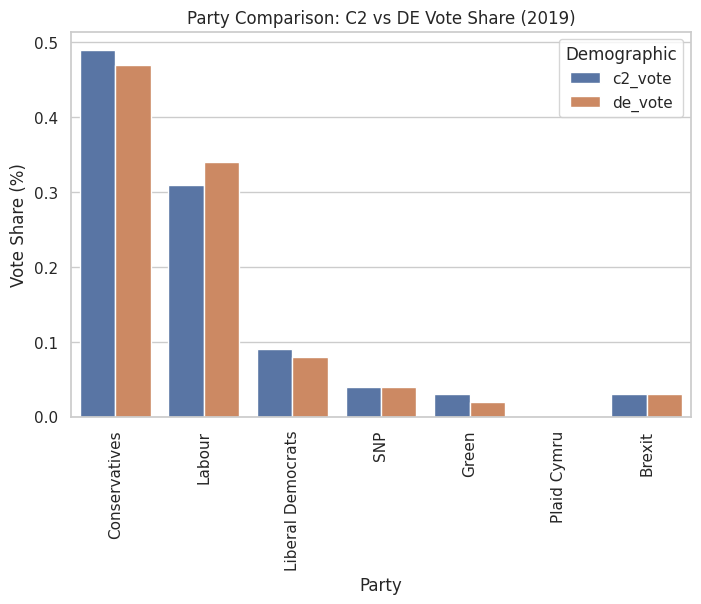

In [14]:
plot_per_party(2019)

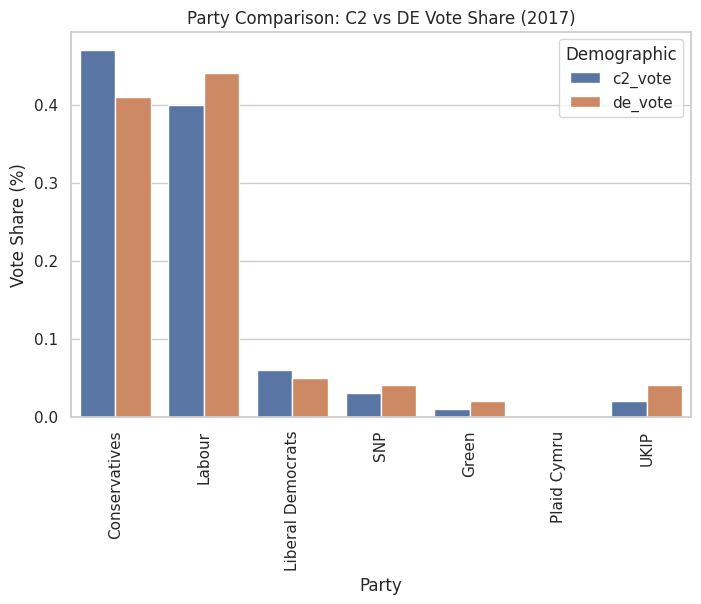

In [15]:
plot_per_party(2017)

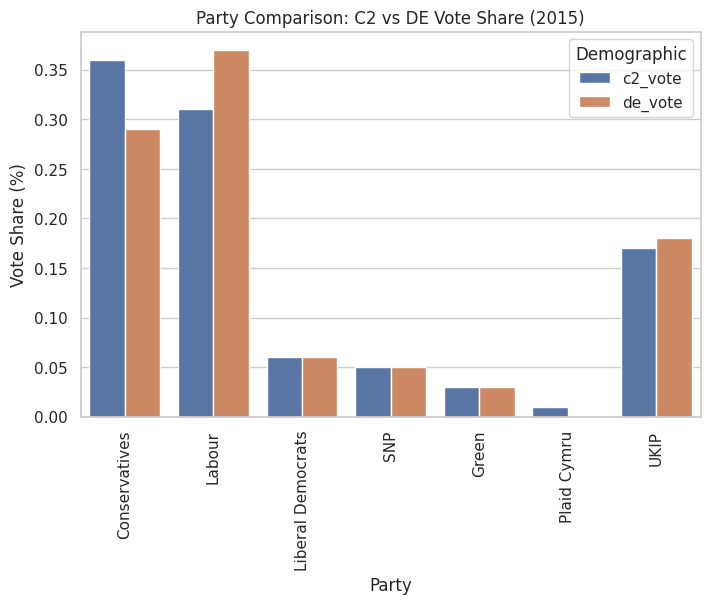

In [17]:
plot_per_party(2015)

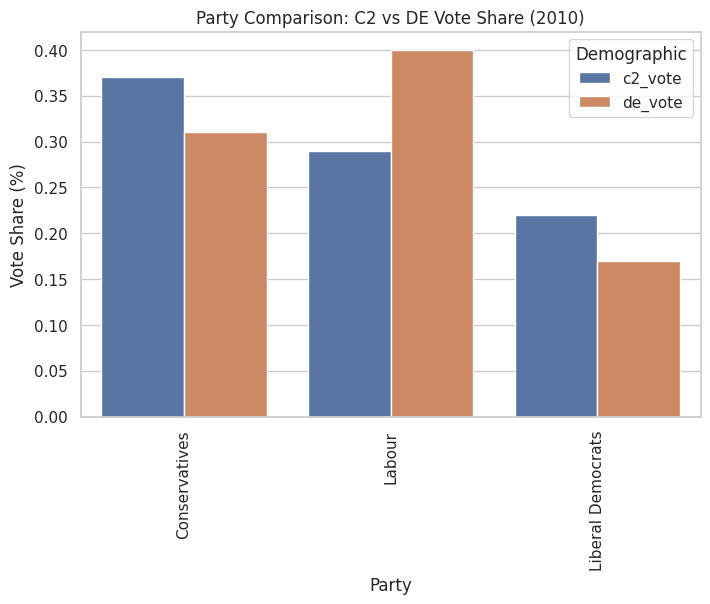

In [18]:
plot_per_party(2010)

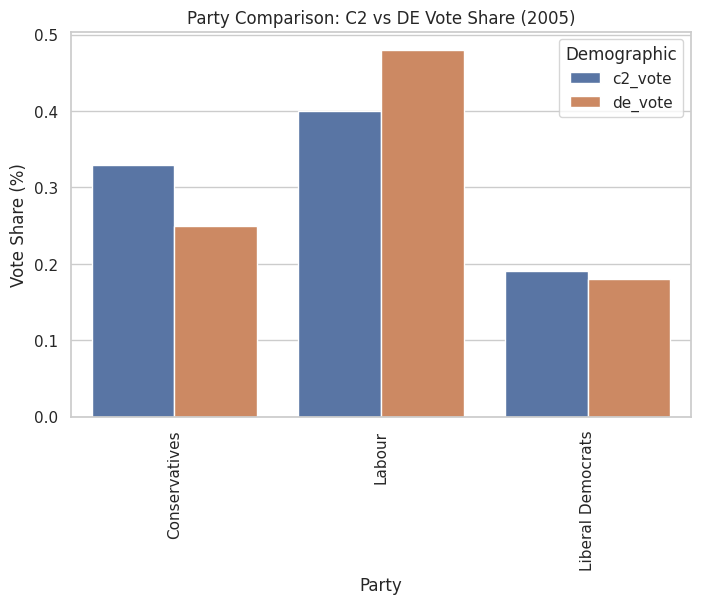

In [19]:
plot_per_party(2005)